# Load libraries

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('./src/python'))
sys.path.append(module_path)
import afim
import xesmf             as xe
import numpy             as np
import xarray            as xr
import cosima_cookbook   as cc
import matplotlib.pyplot as plt
import cartopy.crs       as ccrs
from dask.distributed import Client
%matplotlib inline

In [2]:
cice_prep = afim.cice_prep(os.path.join(os.path.expanduser('~'), 'src', 'python', 'afim_on_gadi.json'))

In [3]:
import re
import fnmatch
import glob
start_year     = '2005'
stop_year      = '2018'
F_mld_prefix   = 'ocean-2d-mld-1-daily-mean-ym_'
F_temp_prefix  = 'ocean-3d-temp-1-daily-mean-ym_'
F_salt_prefix  = 'ocean-3d-salt-1-daily-mean-ym_'
search_pattern = '*{yr:s}_01.nc'.format(yr=start_year)
matches        = []
for root, dirnames, filenames in os.walk(cice_prep.D_ac_om2_out):
    for basename in filenames:
        if fnmatch.fnmatch(basename,search_pattern):
            matches.append(os.path.join(root, basename))
D_out0_parsed = matches[0].split(os.sep)
D_out0        = D_out0_parsed[8]
D_out0_n      = int(re.split('(\d+)',D_out0)[1])
D_outN_n      = ( (int(stop_year) - int(start_year))*4 ) + D_out0_n
yr_out        = int(start_year)
D_cats = [os.path.join(cice_prep.D_ac_om2_out,'output{:d}'.format(188),'ocean'),
          os.path.join(cice_prep.D_ac_om2_out,'output{:d}'.format(188+1),'ocean'),
          os.path.join(cice_prep.D_ac_om2_out,'output{:d}'.format(188+2),'ocean'),
          os.path.join(cice_prep.D_ac_om2_out,'output{:d}'.format(188+3),'ocean')]
P_mld  = np.array((glob.glob(os.path.join(D_cats[0],'{:s}*.nc'.format(F_mld_prefix))),
                   glob.glob(os.path.join(D_cats[1],'{:s}*.nc'.format(F_mld_prefix))),
                   glob.glob(os.path.join(D_cats[2],'{:s}*.nc'.format(F_mld_prefix))),
                   glob.glob(os.path.join(D_cats[3],'{:s}*.nc'.format(F_mld_prefix)))))
m,n    = P_mld.shape
P_mld  = P_mld.reshape((m*n,)).squeeze()
mld    = xr.open_mfdataset(P_mld,chunks={'time':1})
P_temp = np.array((glob.glob(os.path.join(D_cats[0],'{:s}*.nc'.format(F_temp_prefix))),
                   glob.glob(os.path.join(D_cats[1],'{:s}*.nc'.format(F_temp_prefix))),
                   glob.glob(os.path.join(D_cats[2],'{:s}*.nc'.format(F_temp_prefix))),
                   glob.glob(os.path.join(D_cats[3],'{:s}*.nc'.format(F_temp_prefix)))))
m,n    = P_temp.shape
P_temp = P_temp.reshape((m*n,)).squeeze()
temp   = xr.open_mfdataset(P_temp,chunks={'time':1})
P_salt = np.array((glob.glob(os.path.join(D_cats[0],'{:s}*.nc'.format(F_salt_prefix))),
                   glob.glob(os.path.join(D_cats[1],'{:s}*.nc'.format(F_salt_prefix))),
                   glob.glob(os.path.join(D_cats[2],'{:s}*.nc'.format(F_salt_prefix))),
                   glob.glob(os.path.join(D_cats[3],'{:s}*.nc'.format(F_salt_prefix)))))
m,n    = P_salt.shape
P_salt = P_salt.reshape((m*n,)).squeeze()
salt   = xr.open_mfdataset(P_salt,chunks={'time':1})

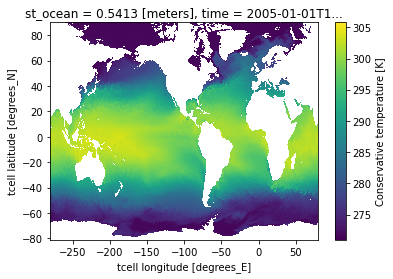

In [4]:
sst    = temp.isel(time=0).sel(st_ocean=0      ,method='nearest').temp
sst.plot()

In [5]:
mld_i = mld.isel(time=0)

In [6]:
T_mld = temp.isel(time=0).sel(st_ocean=mld_i.mld,method='nearest').temp